In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from pylab import rcParams

import tensorflow.compat.v1 as tf

from keras import optimizers, Sequential
from keras.models import Model
from keras.utils import plot_model
from keras.layers import Dense, LSTM, RepeatVector, TimeDistributed
from keras.callbacks import ModelCheckpoint, TensorBoard

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.metrics import recall_score, classification_report, auc, roc_curve
from sklearn.metrics import precision_recall_fscore_support, f1_score

from numpy.random import seed
seed(3)
tf.disable_v2_behavior()
tf.set_random_seed(22)

from sklearn.model_selection import train_test_split

SEED = 123 #used to help randomly select the data points
DATA_SPLIT_PCT = 0.25

rcParams['figure.figsize'] = 8, 6
LABELS = ["Normal","Break"]

In [4]:
df = pd.read_csv("/content/sample_data/P0171_3000.csv") 
df.head(5)  # visualize the data.

,Unnamed: 0,_id,srcValue,y,realTime,srcLatitude,srcLongitude,srcSpeed,srcRPM,srcAPS,...,srcAbsolutePress,srcHybridBatteryT,srcDPF,srcDPFTemp,srcIntakeAirTemp,srcEGT1,srcEGT2,srcUploadTime,srcBattery,srcGyroValue
0,1383,1384,20081612,0,2.020080e+13,20.660911,-103.734322,54,838.00,14.901960,...,87,0,0,0,42,0,0,NaN,13.460,-1.080669
1,1384,1385,20081612,0,2.020080e+13,20.660650,-103.734145,53,1181.50,21.568628,...,87,0,0,0,42,0,0,NaN,13.536,-0.192330
2,1385,1386,20081612,0,2.020080e+13,20.660650,-103.734145,53,1621.75,23.529411,...,87,0,0,0,43,0,0,NaN,13.536,0.198018
3,1386,1387,20081612,0,2.020080e+13,20.660528,-103.734087,53,1731.00,27.058823,...,87,0,0,0,43,0,0,NaN,13.536,-0.281224
4,1387,1388,20081612,0,2.020080e+13,20.660402,-103.734042,53,1953.25,30.588236,...,87,0,0,0,43,0,0,NaN,13.536,-0.039761


In [5]:
sign = lambda x: (1, -1)[x < 0]

def curve_shift(df, shift_by):
    '''
    This function will shift the binary labels in a dataframe.
    The curve shift will be with respect to the 1s. 
    For example, if shift is -2, the following process
    will happen: if row n is labeled as 1, then
    - Make row (n+shift_by):(n+shift_by-1) = 1.
    - Remove row n.
    i.e. the labels will be shifted up to 2 rows up.
    
    Inputs:
    df       A pandas dataframe with a binary labeled column. 
             This labeled column should be named as 'y'.
    shift_by An integer denoting the number of rows to shift.
    
    Output
    df       A dataframe with the binary labels shifted by shift.
    '''

    vector = df['y'].copy()
    for s in range(abs(shift_by)):
        tmp = vector.shift(sign(shift_by))
        tmp = tmp.fillna(0)
        vector += tmp
    labelcol = 'y'
    # Add vector to the df
    df.insert(loc=0, column=labelcol+'tmp', value=vector)
    # Remove the rows with labelcol == 1.
    df = df.drop(df[df[labelcol] == 1].index)
    # Drop labelcol and rename the tmp col as labelcol
    df = df.drop(labelcol, axis=1)
    df = df.rename(columns={labelcol+'tmp': labelcol})
    # Make the labelcol binary
    df.loc[df[labelcol] > 0, labelcol] = 1

    return df

In [6]:
'''
Shift the data by 2 units, equal to 4 minutes.

Test: Testing whether the shift happened correctly.
'''
print('Before shifting')  # Positive labeled rows before shifting.
one_indexes = df.index[df['y'] == 1]
display(df.iloc[(one_indexes[0]-3):(one_indexes[0]+2), 0:5].head(n=5))

# Shift the response column y by 2 rows to do a 4-min ahead prediction.
df = curve_shift(df, shift_by = -10)

print('After shifting')  # Validating if the shift happened correctly.
display(df.iloc[(one_indexes[0]-4):(one_indexes[0]+1), 0:5].head(n=5))  

Before shifting


,Unnamed: 0,_id,srcValue,y,realTime
596,1979,1980,20081612,0,2.020080e+13
597,1980,1981,20081612,0,2.020080e+13
598,1981,1982,20081612,0,2.020080e+13
599,1982,1983,20081612,1,2.020080e+13
600,949,950,20112601,0,2.020110e+13


After shifting


,y,Unnamed: 0,_id,srcValue,realTime
595,1.0,1978,1979,20081612,2.020080e+13
596,1.0,1979,1980,20081612,2.020080e+13
597,1.0,1980,1981,20081612,2.020080e+13
598,1.0,1981,1982,20081612,2.020080e+13
600,0.0,949,950,20112601,2.020110e+13


In [7]:
# Remove time column, and the categorical columns
df = df[['y', 'srcSpeed', 'srcRPM', 'srcMAF', 'srcEngineLoad', 'srcEngineCoolantTemp']]


In [8]:
input_X = df.loc[:, df.columns != 'y'].values  # converts the df to a numpy array
input_y = df['y'].values

n_features = input_X.shape[1]  # number of features

In [9]:
def temporalize(X, y, lookback):
    output_X = []
    output_y = []
    for i in range(len(X)-lookback-1):
        t = []
        for j in range(1,lookback+1):
            # Gather past records upto the lookback period
            t.append(X[[(i+j+1)], :])
        output_X.append(t)
        output_y.append(y[i+lookback+1])
    return output_X, output_y

In [10]:
'''
Test: The 3D tensors (arrays) for LSTM are forming correctly.
'''
print('First instance of y = 1 in the original data')
display(df.iloc[(np.where(np.array(input_y) == 1)[0][0]-5):(np.where(np.array(input_y) == 1)[0][0]+1), ])

lookback = 60  # Equivalent to 10 min of past data.
# Temporalize the data
X, y = temporalize(X = input_X, y = input_y, lookback = lookback)

print('For the same instance of y = 1, we are keeping past 5 samples in the 3D predictor array, X.')
display(pd.DataFrame(np.concatenate(X[np.where(np.array(y) == 1)[0][0]], axis=0 ))) 

First instance of y = 1 in the original data


,y,srcSpeed,srcRPM,srcMAF,srcEngineLoad,srcEngineCoolantTemp
584,0.0,79,2356.75,11.02,53.725490,84
585,0.0,79,2376.25,11.09,58.039215,84
586,0.0,80,2383.00,12.57,59.607840,84
587,0.0,80,2400.00,13.83,61.176470,83
588,0.0,81,2423.25,13.28,61.568626,83
589,1.0,81,2436.50,13.43,61.568626,83


For the same instance of y = 1, we are keeping past 5 samples in the 3D predictor array, X.


,0,1,2,3,4
0,71.0,2140.50,7.05,43.921570,86.0
1,71.0,2135.25,7.05,31.764706,86.0
2,71.0,2130.00,6.19,31.764706,86.0
3,71.0,2127.00,7.15,34.509804,86.0
4,71.0,2131.50,7.99,39.607840,86.0
5,71.0,2132.75,8.23,45.882355,86.0
6,71.0,2146.50,8.63,46.666668,86.0
7,71.0,2196.50,5.91,21.568628,86.0
8,71.0,2206.50,6.39,29.803920,86.0
9,71.0,2212.00,6.90,33.333332,86.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), test_size=DATA_SPLIT_PCT, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=DATA_SPLIT_PCT, random_state=SEED)


X_train.shape

(1650, 60, 1, 5)

In [12]:
X_train_y0 = X_train[y_train==0]
X_train_y1 = X_train[y_train==1]

X_valid_y0 = X_valid[y_valid==0]
X_valid_y1 = X_valid[y_valid==1]


In [13]:
X_train = X_train.reshape(X_train.shape[0], lookback, n_features)
X_train_y0 = X_train_y0.reshape(X_train_y0.shape[0], lookback, n_features)
X_train_y1 = X_train_y1.reshape(X_train_y1.shape[0], lookback, n_features)

X_test = X_test.reshape(X_test.shape[0], lookback, n_features)

X_valid = X_valid.reshape(X_valid.shape[0], lookback, n_features)
X_valid_y0 = X_valid_y0.reshape(X_valid_y0.shape[0], lookback, n_features)
X_valid_y1 = X_valid_y1.reshape(X_valid_y1.shape[0], lookback, n_features)

In [14]:
def flatten(X):
    '''
    Flatten a 3D array.
    
    Input
    X            A 3D array for lstm, where the array is sample x timesteps x features.
    
    Output
    flattened_X  A 2D array, sample x features.
    '''
    flattened_X = np.empty((X.shape[0], X.shape[2]))  # sample x features array.
    for i in range(X.shape[0]):
        flattened_X[i] = X[i, (X.shape[1]-1), :]
    return(flattened_X)

def scale(X, scaler):
    '''
    Scale 3D array.

    Inputs
    X            A 3D array for lstm, where the array is sample x timesteps x features.
    scaler       A scaler object, e.g., sklearn.preprocessing.StandardScaler, sklearn.preprocessing.normalize
    
    Output
    X            Scaled 3D array.
    '''
    for i in range(X.shape[0]):
        X[i, :, :] = scaler.transform(X[i, :, :])
        
    return X

In [15]:
# Initialize a scaler using the training data.
scaler = StandardScaler().fit(flatten(X_train_y0))

In [16]:
X_train_y0_scaled = scale(X_train_y0, scaler)
X_train_y1_scaled = scale(X_train_y1, scaler)
X_train_scaled = scale(X_train, scaler)

In [17]:
'''
Test: Check if the scaling is correct.

The test succeeds if all the column means 
and variances are 0 and 1, respectively, after
flattening.
'''
a = flatten(X_train_y0_scaled)
print('colwise mean', np.mean(a, axis=0).round(6))
print('colwise variance', np.var(a, axis=0))

colwise mean [-0. -0. -0.  0. -0.]
colwise variance [1. 1. 1. 1. 1.]


In [18]:
X_valid_scaled = scale(X_valid, scaler)
X_valid_y0_scaled = scale(X_valid_y0, scaler)

X_test_scaled = scale(X_test, scaler)

In [19]:
timesteps =  X_train_y0_scaled.shape[1] # equal to the lookback
n_features =  X_train_y0_scaled.shape[2] # 59

epochs = 200
batch = 32
lr = 0.0001

In [20]:
lstm_autoencoder = Sequential()
# Encoder
lstm_autoencoder.add(LSTM(32, activation='relu', input_shape=(timesteps, n_features), return_sequences=True))
lstm_autoencoder.add(LSTM(16, activation='relu', return_sequences=False))
lstm_autoencoder.add(RepeatVector(timesteps))
# Decoder
lstm_autoencoder.add(LSTM(16, activation='relu', return_sequences=True))
lstm_autoencoder.add(LSTM(32, activation='relu', return_sequences=True))
lstm_autoencoder.add(TimeDistributed(Dense(n_features)))

lstm_autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 32)            4864      
                                                                 
 lstm_1 (LSTM)               (None, 16)                3136      
                                                                 
 repeat_vector (RepeatVector  (None, 60, 16)           0         
 )                                                               
                                                                 
 lstm_2 (LSTM)               (None, 60, 16)            2112      
                                                                 
 lstm_3 (LSTM)               (None, 60, 32)            6272      
                                                                 
 time_distributed (TimeDistr  (None, 60, 5)            165       
 ibuted)                                                

In [21]:
adam = optimizers.Adam(lr)
lstm_autoencoder.compile(loss='mse', optimizer=adam)

cp = ModelCheckpoint(filepath="lstm_autoencoder_classifier.h5",
                               save_best_only=True,
                               verbose=0)

tb = TensorBoard(log_dir='./logs',
                histogram_freq=0,
                write_graph=True,
                write_images=True)

lstm_autoencoder_history = lstm_autoencoder.fit(X_train_y0_scaled, X_train_y0_scaled, 
                                                epochs=epochs, 
                                                batch_size=batch, 
                                                validation_data=(X_valid_y0_scaled, X_valid_y0_scaled),
                                                verbose=2).history

Train on 1623 samples, validate on 536 samples
Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/engine/training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


1623/1623 - 6s - loss: 0.9714 - val_loss: 0.9414 - 6s/epoch - 3ms/sample
Epoch 2/200
1623/1623 - 4s - loss: 0.8848 - val_loss: 0.8621 - 4s/epoch - 3ms/sample
Epoch 3/200
1623/1623 - 6s - loss: 0.7952 - val_loss: 0.7918 - 6s/epoch - 4ms/sample
Epoch 4/200
1623/1623 - 4s - loss: 0.7296 - val_loss: 0.7235 - 4s/epoch - 3ms/sample
Epoch 5/200
1623/1623 - 4s - loss: 0.6772 - val_loss: 0.6775 - 4s/epoch - 2ms/sample
Epoch 6/200
1623/1623 - 6s - loss: 0.6266 - val_loss: 0.6279 - 6s/epoch - 4ms/sample
Epoch 7/200
1623/1623 - 4s - loss: 0.5981 - val_loss: 0.6151 - 4s/epoch - 3ms/sample
Epoch 8/200
1623/1623 - 4s - loss: 0.5735 - val_loss: 0.5813 - 4s/epoch - 3ms/sample
Epoch 9/200
1623/1623 - 6s - loss: 0.5450 - val_loss: 0.5574 - 6s/epoch - 4ms/sample
Epoch 10/200
1623/1623 - 4s - loss: 0.5219 - val_loss: 0.5320 - 4s/epoch - 3ms/sample
Epoch 11/200
1623/1623 - 4s - loss: 0.4989 - val_loss: 0.5087 - 4s/epoch - 3ms/sample
Epoch 12/200
1623/1623 - 6s - loss: 0.4785 - val_loss: 0.4841 - 6s/epoch - 

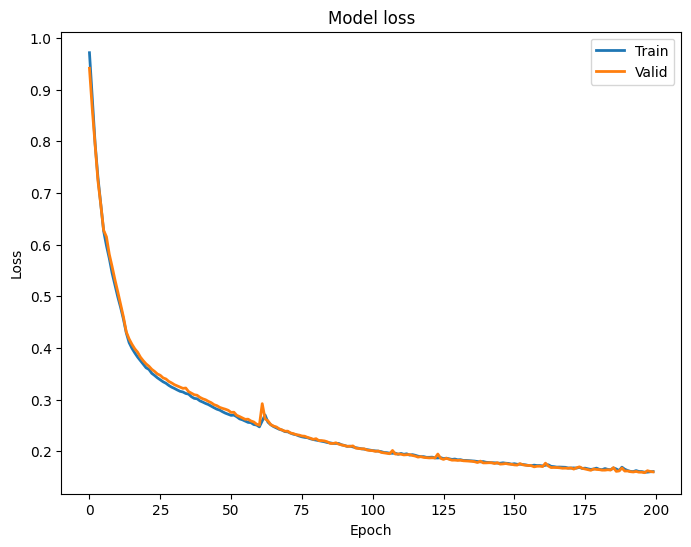

In [22]:
plt.plot(lstm_autoencoder_history['loss'], linewidth=2, label='Train')
plt.plot(lstm_autoencoder_history['val_loss'], linewidth=2, label='Valid')
plt.legend(loc='upper right')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


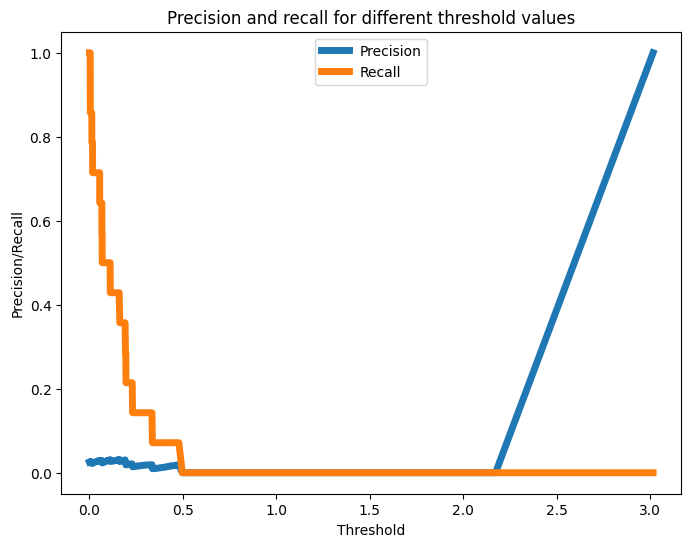

In [23]:
valid_x_predictions = lstm_autoencoder.predict(X_valid_scaled)
mse = np.mean(np.power(flatten(X_valid_scaled) - flatten(valid_x_predictions), 2), axis=1)

error_df = pd.DataFrame({'Reconstruction_error': mse,
                        'True_class': y_valid.tolist()})

precision_rt, recall_rt, threshold_rt = precision_recall_curve(error_df.True_class, error_df.Reconstruction_error)
plt.plot(threshold_rt, precision_rt[1:], label="Precision",linewidth=5)
plt.plot(threshold_rt, recall_rt[1:], label="Recall",linewidth=5)
plt.title('Precision and recall for different threshold values')
plt.xlabel('Threshold')
plt.ylabel('Precision/Recall')
plt.legend()
plt.show()

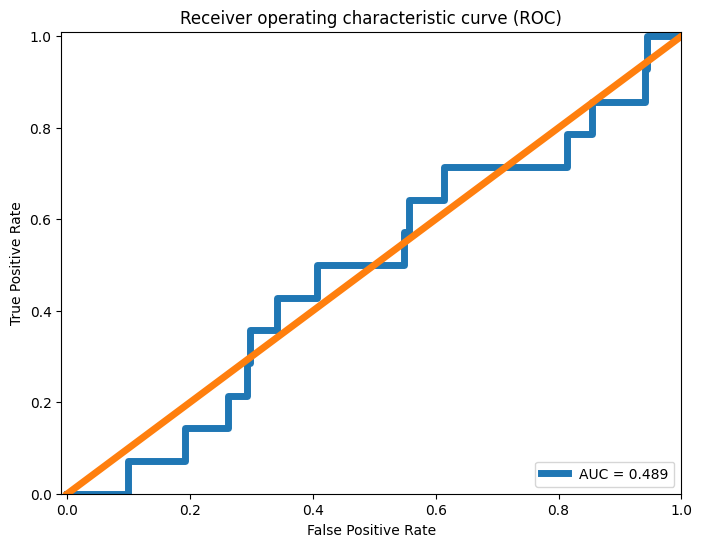

In [24]:
false_pos_rate, true_pos_rate, thresholds = roc_curve(error_df.True_class, error_df.Reconstruction_error)
roc_auc = auc(false_pos_rate, true_pos_rate,)

plt.plot(false_pos_rate, true_pos_rate, linewidth=5, label='AUC = %0.3f'% roc_auc)
plt.plot([0,1],[0,1], linewidth=5)

plt.xlim([-0.01, 1])
plt.ylim([0, 1.01])
plt.legend(loc='lower right')
plt.title('Receiver operating characteristic curve (ROC)')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()